In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import cv2
import skimage.morphology as skm
from skimage import measure, color
%matplotlib inline
mpl.rc('figure',  figsize=(20, 10))
mpl.rc('image', cmap='gray')


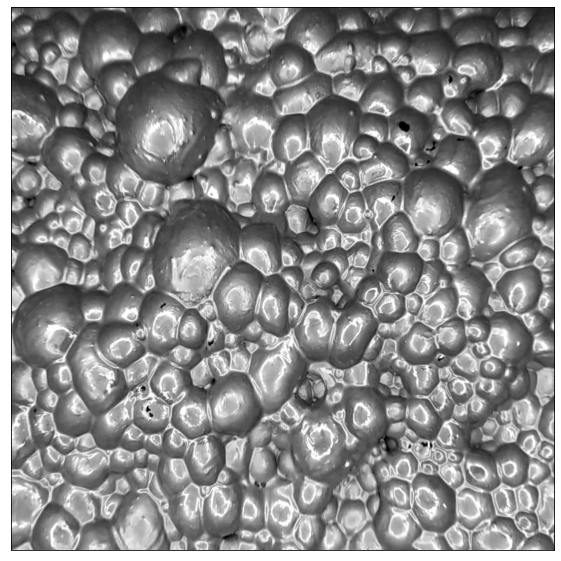

In [89]:
# Read the image and convert it to gray scale
img = cv2.imread("./bubble_raw.png")
gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

plt.imshow(gray_img)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


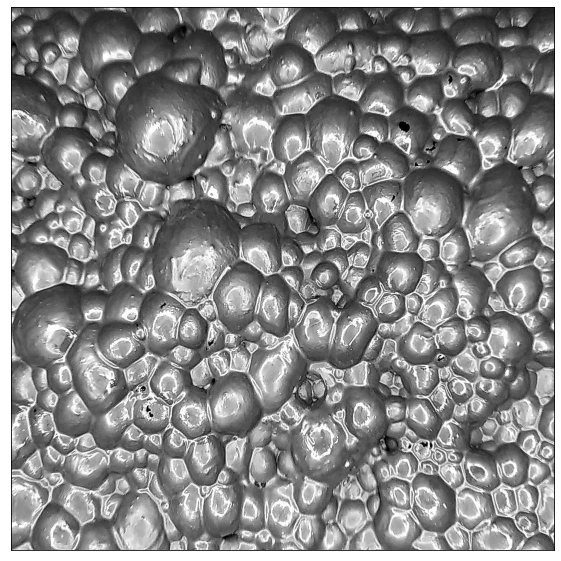

In [55]:
# sharpen operation
kernel_pre1 = np.array([[0, -1, 0],[-1, 5, -1],[0, -1, 0]])
img_sharpen = cv2.filter2D(gray_img,-1,kernel_pre1)

# Calculate the minimum and maximum values in the array
min_value = img_sharpen.min()
max_value = img_sharpen.max()

# Stretch the contrast of the image by scaling the pixel values to the range 0-255
scaled_image = (img_sharpen - min_value) * (255 / (max_value - min_value))

plt.imshow(scaled_image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


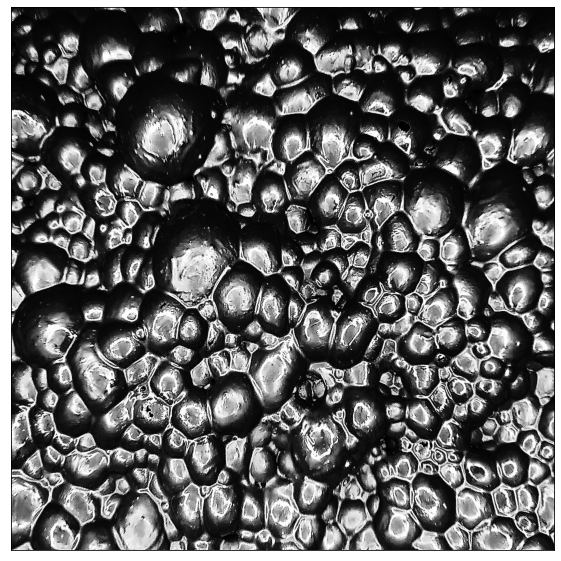

In [57]:
r1=80
r2=200
s1=30
s2=210

al = s1/r1
bt = (s2-s1)/(r2-r1)
gm = (255-s2)/(255-r2)
c1 = s1-bt*r1
c2 = s2-gm*r2
img = img_sharpen
d = img
for i in range(len(img)):
    for j in range(len(img[0])):
        if (img[i][j] < r1):
            d[i][j] = al*img[i][j]
        elif (r1 <= img[i][j] < r2):
            d[i][j] = bt*img[i][j] + c1
        else:
            d[i][j] = gm*img[i][j] + c2


plt.imshow(d)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

img_sharpen = d

#### If you couldnt extend the segmentation to the full bubble just find out a formula to deduct the size of the bubble from its white spot

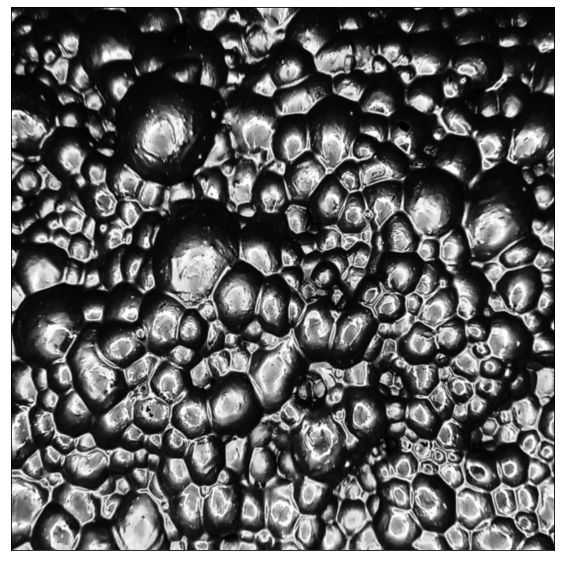

In [58]:
# gaussien blur operation 
kernel_pre2 = np.array([[1, 4, 6, 4, 1],[4, 16, 24, 16, 4],[6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])/256  
img_blur = cv2.filter2D(img_sharpen,-1,kernel_pre2)

plt.imshow(img_blur)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


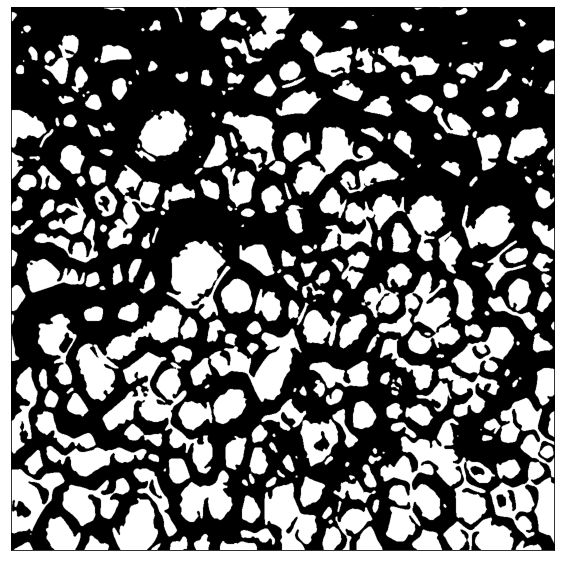

In [59]:
# edges extraction based on the adaptive treshold

ret, img_AT_1 = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
img_AT_1 = cv2.medianBlur(255-img_AT_1, 7)


#img_AT_1 = cv2.adaptiveThreshold(img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 3)
closing1 = skm.area_closing(img_AT_1, area_threshold=250, connectivity=1)

plt.imshow(closing1)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


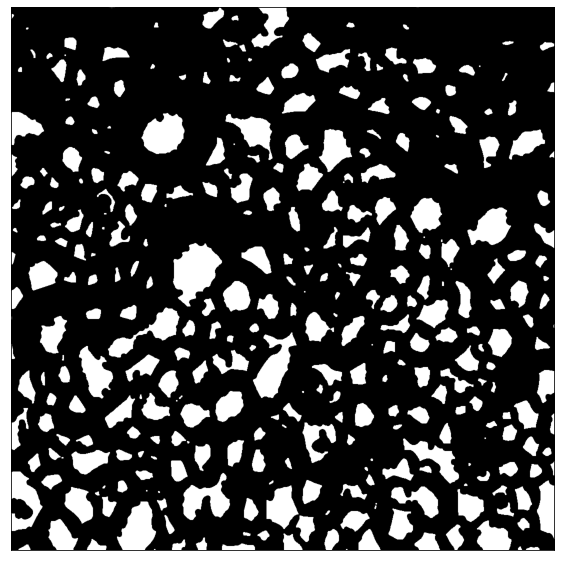

In [94]:
# Extraction of sure forground using distance transform, treshold and opening algorithms

# distance transform allow more controle than erosion
dist_transform = cv2.distanceTransform(closing1, cv2.DIST_L2, 5)
ret1, sure_fg1 = cv2.threshold(dist_transform, 0.1*dist_transform.max(), 255, cv2.THRESH_BINARY)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(sure_fg1, cv2.MORPH_OPEN, kernel, iterations=1)
sure_fg2 = opening.astype(np.uint8)

plt.imshow(sure_fg2)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show() 


In [95]:
# Creating background image (white image all value == 255)
# we don't need to use dilation because in our case we dont have a background
size_img = (1088, 1088)
sure_bg = np.full(size_img, 255, np.uint8)


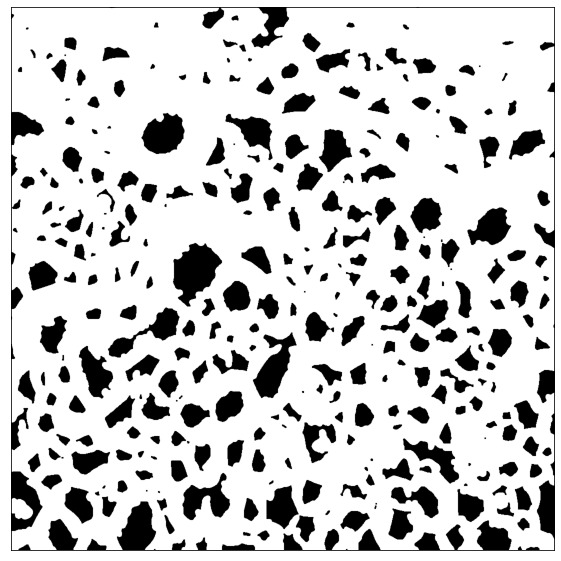

In [96]:
# Finding unknown region
unknown1 = cv2.subtract(sure_bg,sure_fg2)

plt.imshow(unknown1)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


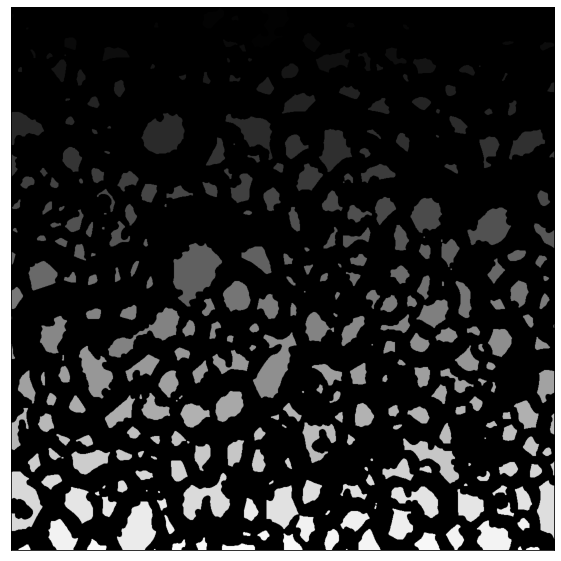

In [97]:
from skimage import morphology


# Marker labelling
ret1, markers1 = cv2.connectedComponents(sure_fg2)
dilated_image = morphology.dilation(markers1)
erroded_image = morphology.erosion(dilated_image)
# Add one to all labels so that sure background is not 0, but 1
markers1 = markers1 + 1
# Now, mark the region of unknown with zero
markers1[unknown1 == 255] = 0

plt.imshow(markers1)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


In [98]:
# apply watershed algorithm

markers1 = cv2.watershed(img, markers1)
markers1_img = markers1.astype(np.uint8)
markers1b = color.label2rgb(markers1, bg_label=0)


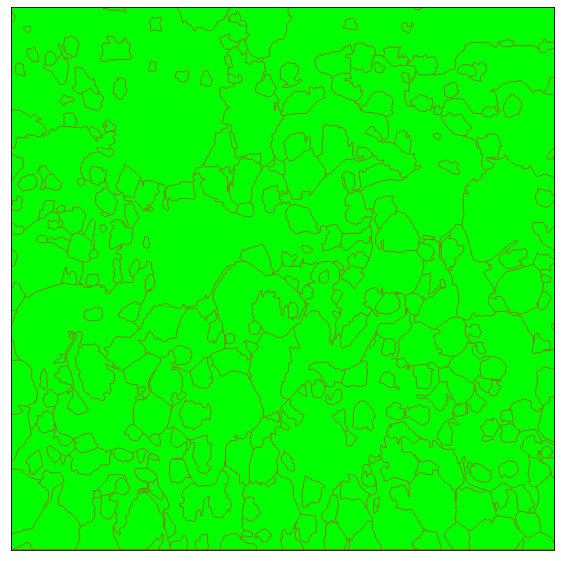

In [100]:
img1 = np.copy(img)
img1[markers1 == -1] = [255,0,0]
img1[markers1 > 0] = [0, 255, 0]

plt.imshow(img1)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()
